In [112]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Roman",
    "font.size": 17
})

In [12]:
base_path = '/Users/Simon/Documents/PhD/Projects/CausalBottleneckModels/results/tf'

In [103]:
def plot_single_tf_run(results_arr, x_values, ax, y_name='mae', nonlinear=False):
    cond_sets = ['x', 'bn']

    # Reformat data into dataframe for plotting
    n_seeds, n_x_values = results_arr.shape

    # model_data = np.repeat(cond_sets, n_seeds * n_x_values)
    model_data = np.repeat(['$\mathbf{X}_3$', '$\hat{\mathbf{Z}}_{(3,1)}$'], n_seeds * n_x_values)
    x_values_data = np.tile(np.repeat([str(x) for x in x_values], n_seeds), len(cond_sets))

    y_data = np.empty(shape=model_data.shape)

    # Loop over seeds
    for j in range(n_x_values):
        # Loop over x values
        for i in range(n_seeds):
            for k, predictor in enumerate(cond_sets):
                # Just a fancy way of flattening an array of dicts of dicts
                y_data[i+j*n_seeds+k*n_seeds*n_x_values] = results_arr[i, j][predictor][y_name]

    plot_df = pd.DataFrame({'Cond. variable': model_data,
                            '$n$': x_values_data,
                            y_name: y_data})

    ax = sns.lineplot(ax=ax, data=plot_df, x='$n$', y=y_name, hue='Cond. variable', style='Cond. variable',
                      palette=["#80b3ff", "#4d94ff"] if not nonlinear else ["#a1c9a7", "#68ca75"], dashes=[(2, 2), ''])

    if not nonlinear:
        ax.set_ylabel("MAE")
        ax.set_title("Linear")
    else:
        ax.set_ylabel("")
        ax.set_title("Nonlinear")

# Linear

In [95]:
linear_path = os.path.join(base_path, 'linear', '100_110_150_500_1000_results.npy')

linear_results_arr = np.load(linear_path, allow_pickle=True)

# Nonlinear

In [76]:
nonlinear_path = os.path.join(base_path, 'nonlinear', '10_20_50_500_1000_results.npy')

nonlinear_results_arr = np.load(nonlinear_path, allow_pickle=True)

/var/folders/3t/tsy826vs2hqbz3y19mzxzp1w0000gn/T/ipykernel_27591/4182246757.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


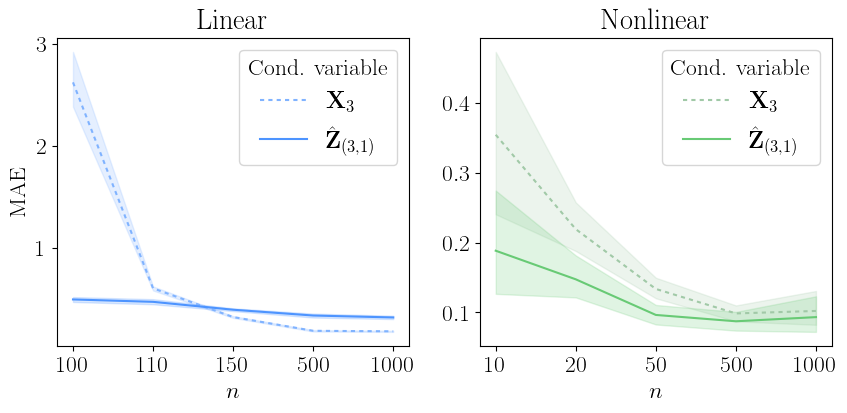

In [113]:
fig, axs = plt.subplots(1, 2, figsize=[10, 4])

plot_single_tf_run(linear_results_arr, x_values=[100, 110, 150, 500, 1000], ax=axs[0])
plot_single_tf_run(nonlinear_results_arr, x_values=[10, 20, 50, 500, 1000], ax=axs[1], nonlinear=True)

# axs[0].legend(['first', 'second'])

fig.show()

In [114]:
save_path = os.path.join(base_path, 'tf_fig_wide.pdf')

fig.savefig(save_path, transparent=True, bbox_inches='tight')

In [11]:
test[0, 0]['x'].keys()

dict_keys(['mse', 'mae', 'var'])